In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from scipy.stats import pearsonr, spearmanr

adata_sc = sc.read_h5ad("../../save_normal_results.h5ad", backed = 'r')
adata_rap = sc.read_h5ad("../../save_rapids_results.h5ad", backed = 'r')

# Ensure same cell order
assert (adata_sc.obs_names == adata_rap.obs_names).all(), "Cell order mismatch!"

In [2]:
pca_sc = adata_sc.obsm["X_pca"]
pca_rap = adata_rap.obsm["X_pca"]

# Per-component Pearson correlation (sign-flip aware)
n_pcs = min(pca_sc.shape[1], pca_rap.shape[1])
correlations = []
for i in range(n_pcs):
    r, _ = pearsonr(pca_sc[:, i], pca_rap[:, i])
    correlations.append(abs(r))  # abs since PCs can be sign-flipped

pca_corr_df = pd.DataFrame({"PC": range(1, n_pcs+1), "abs_pearson_r": correlations})
print(pca_corr_df.head(20))
print(f"\nMean |r| across top 20 PCs: {np.mean(correlations[:20]):.4f}")

# Overall embedding similarity via Procrustes
from scipy.spatial import procrustes
_, _, disparity = procrustes(pca_sc[:, :n_pcs], pca_rap[:, :n_pcs])
print(f"Procrustes disparity (0=identical): {disparity:.4f}")

    PC  abs_pearson_r
0    1            1.0
1    2            1.0
2    3            1.0
3    4            1.0
4    5            1.0
5    6            1.0
6    7            1.0
7    8            1.0
8    9            1.0
9   10            1.0
10  11            1.0
11  12            1.0
12  13            1.0
13  14            1.0
14  15            1.0
15  16            1.0
16  17            1.0
17  18            1.0
18  19            1.0
19  20            1.0

Mean |r| across top 20 PCs: 1.0000
Procrustes disparity (0=identical): 0.0000


In [3]:
from scipy.sparse import csr_matrix

def get_adjacency(adata):
    conn = adata.obsp["connectivities"]
    if not issparse(conn):
        conn = csr_matrix(conn)
    # Binarize
    conn = conn.copy()
    conn.data = np.ones_like(conn.data)
    return conn

adj_sc  = get_adjacency(adata_sc)
adj_rap = get_adjacency(adata_rap)

# Intersection and union of edges
intersection = adj_sc.multiply(adj_rap)
union = (adj_sc + adj_rap)
union.data = np.ones_like(union.data)

n_sc    = adj_sc.nnz
n_rap   = adj_rap.nnz
n_shared = intersection.nnz
jaccard  = n_shared / union.nnz

print(f"Scanpy edges:       {n_sc}")
print(f"RAPIDS edges:       {n_rap}")
print(f"Shared edges:       {n_shared}")
print(f"Jaccard similarity: {jaccard:.4f}")
print(f"% of scanpy edges retained in RAPIDS: {n_shared/n_sc*100:.1f}%")

# Per-cell neighbor overlap
shared_per_cell = np.array(intersection.sum(axis=1)).flatten()
total_per_cell  = np.array(adj_sc.sum(axis=1)).flatten()
per_cell_overlap = shared_per_cell / np.maximum(total_per_cell, 1)

print(f"\nPer-cell neighbor overlap — mean: {per_cell_overlap.mean():.4f}, "
      f"median: {np.median(per_cell_overlap):.4f}")

Scanpy edges:       87086906
RAPIDS edges:       87087490
Shared edges:       87037852
Jaccard similarity: 0.9989
% of scanpy edges retained in RAPIDS: 99.9%

Per-cell neighbor overlap — mean: 0.9994, median: 1.0000


In [4]:
from scipy.spatial.distance import cdist

umap_sc  = adata_sc.obsm["X_umap"]
umap_rap = adata_rap.obsm["X_umap"]

# Normalize each to [0,1] before comparing (UMAPs live in arbitrary coordinate spaces)
def minmax(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

umap_sc_norm  = minmax(umap_sc)
umap_rap_norm = minmax(umap_rap)

# Per-cell Euclidean distance between normalized coords
dists = np.linalg.norm(umap_sc_norm - umap_rap_norm, axis=1)
print(f"Per-cell UMAP displacement (normalized) — mean: {dists.mean():.4f}, "
      f"median: {np.median(dists):.4f}, max: {dists.max():.4f}")

# Spearman correlation of pairwise distance matrices (subsample for speed)
n_sample = 500
idx = np.random.choice(len(umap_sc), n_sample, replace=False)
pdist_sc  = cdist(umap_sc[idx],  umap_sc[idx])
pdist_rap = cdist(umap_rap[idx], umap_rap[idx])

triu = np.triu_indices(n_sample, k=1)
rho, pval = spearmanr(pdist_sc[triu], pdist_rap[triu])
print(f"\nSpearman r of pairwise distances (n={n_sample} cells): {rho:.4f} (p={pval:.2e})")

Per-cell UMAP displacement (normalized) — mean: 0.3983, median: 0.3850, max: 0.8763

Spearman r of pairwise distances (n=500 cells): 0.5303 (p=0.00e+00)


Cluster ARI: 0.0003


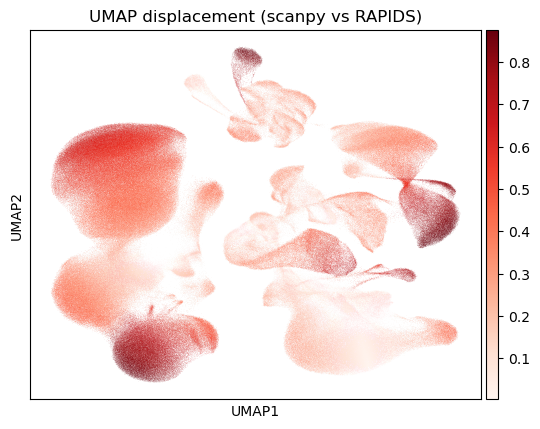

In [5]:
# 1. Are the cluster/cell type assignments actually concordant?
# If clustering was done on neighbors (which are 99.9% identical),
# your cluster labels should be nearly the same regardless of UMAP
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(adata_sc.obs["leiden"], adata_rap.obs["leiden"])
print(f"Cluster ARI: {ari:.4f}")  # expect ~1.0 given neighbor similarity

# 2. Visualize displacement magnitude per cell — are outliers a specific cell type?
adata_sc.obs["umap_displacement"] = dists  # from the snippet above

sc.pl.umap(adata_sc, color="umap_displacement", cmap="Reds", 
           title="UMAP displacement (scanpy vs RAPIDS)")

In [6]:
# Quick diagnostic
print(adata_sc.obs["leiden"].value_counts().shape[0], "clusters in scanpy")
print(adata_rap.obs["leiden"].value_counts().shape[0], "clusters in RAPIDS")

print(adata_sc.obs["leiden"].value_counts().sort_index())
print(adata_rap.obs["leiden"].value_counts().sort_index())

32 clusters in scanpy
153720 clusters in RAPIDS
leiden
0     101536
1      95678
2      92108
3      80619
4      74434
5      72195
6      65979
7      59324
8      58132
9      55206
10     49608
11     46359
12     33764
13     30055
14     29108
15     25406
16     23114
17     20968
18     20876
19     15003
20     14768
21     13962
22     13407
23     12623
24     12498
25     10137
26     10049
27      9647
28      8492
29      7338
30      6420
31      3152
Name: count, dtype: int64
leiden
0         26
1         30
2         33
3         24
4         32
          ..
153715     4
153716     4
153717     5
153718     5
153719     5
Name: count, Length: 153720, dtype: int64


In [7]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# AMI is more robust to label permutation than ARI
ami = adjusted_mutual_info_score(adata_sc.obs["leiden"], adata_rap.obs["leiden"])
print(f"Cluster AMI: {ami:.4f}")  # if this is high (~0.9+), partitions are concordant
# just with different label numbering

Cluster AMI: 0.2902
